In [1]:
# =============================================================================
# PAPYRUS FULL DATASET CLASSIFICATION PIPELINE (NO ACTIVITY FILTER)
# =============================================================================
# This notebook processes ALL molecules in Papyrus (no activity filter)
# Steps:
# 1. Read the full Papyrus dataset (ALL records)
# 2. Extract molecular features (parallelized)
# 3. Classify molecules using pre-trained Random Forest
# 4. Rank targets by peptide count
# 5. Generate analysis plots
# =============================================================================

import sys
import os
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import joblib
import re
import ast
from multiprocessing import Pool, cpu_count
import time

# Add mol_utils to path
sys.path.insert(0, "/home/ec2-user/mol-utils/src")

from rdkit import Chem
from mol_utils import MolecularClassifier

print(f"Python: {sys.executable}")

# =============================================================================
# CONFIGURATION
# =============================================================================
PAPYRUS_FILE = "/fsx/amira/papyrus_50.5/05.5_combined_set_without_stereochemistry.tsv.xz"
MODEL_PATH = "/fsx/alex/MolecularTypeClassifier-1/scratch/molecular_classifier_model.joblib"
ENCODER_PATH = "/fsx/alex/MolecularTypeClassifier-1/scratch/molecular_classifier_label_encoder.joblib"
OUTPUT_DIR = "/fsx/amira/papyrus_50.5_results/classified_full_no_filter"

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Input: {PAPYRUS_FILE}")
print(f"Output: {OUTPUT_DIR}")
print(f"\nNOTE: Processing ALL records (no activity filter)")


Python: /home/ec2-user/MolecularTypeClassifier/.pixi/envs/default/bin/python
Input: /fsx/amira/papyrus_50.5/05.5_combined_set_without_stereochemistry.tsv.xz
Output: /fsx/amira/papyrus_50.5_results/classified_full_no_filter

NOTE: Processing ALL records (no activity filter)


In [2]:
# =============================================================================
# Initialize Classifier and Load Model
# =============================================================================

classifier = MolecularClassifier()
print("MolecularClassifier initialized")

# Load pre-trained model
clf = joblib.load(MODEL_PATH)
label_encoder = joblib.load(ENCODER_PATH)
print(f"Model loaded from {MODEL_PATH}")
print(f"Classes: {label_encoder.classes_}")


MolecularClassifier initialized
Model loaded from /fsx/alex/MolecularTypeClassifier-1/scratch/molecular_classifier_model.joblib
Classes: ['can_peptide' 'sm' 'unwanted']


In [3]:
# =============================================================================
# Feature Extraction Functions
# =============================================================================

def mol_from_smiles(smiles: str):
    """Safe RDKit SMILES to Mol conversion."""
    if not isinstance(smiles, str) or not smiles.strip():
        return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        try:
            mol = Chem.MolFromSmiles(smiles, sanitize=False)
            if mol is not None:
                Chem.SanitizeMol(mol)
        except Exception:
            return None
    return mol


def parse_feature_string(feature_str) -> dict:
    """Parse MolecularFeatures string to dict."""
    if not isinstance(feature_str, str) or not feature_str.strip():
        return {}
    
    s = feature_str.strip()
    if s.startswith("MolecularFeatures(") and s.endswith(")"):
        s = s[len("MolecularFeatures("):-1]
    
    pattern_dict = {}
    m = re.search(r"pattern_counts\s*=\s*(\{.*\})", s)
    if m:
        pattern_text = m.group(1)
        s = s[:m.start()].rstrip().rstrip(",").rstrip()
        try:
            pattern_dict = ast.literal_eval(pattern_text)
        except Exception:
            pattern_dict = {}
    
    features = {}
    for kv in re.split(r"\s*,\s*", s):
        if "=" not in kv:
            continue
        k, v = kv.split("=", 1)
        k = k.strip()
        v = v.strip()
        try:
            if re.fullmatch(r"[-+]?(?:\d+\.\d*|\d*\.\d+)(?:[eE][-+]?\d+)?", v):
                v = float(v)
            elif re.fullmatch(r"[-+]?\d+", v):
                v = int(v)
        except Exception:
            pass
        features[k] = v
    
    for pk, pv in pattern_dict.items():
        features[f"pattern_{pk}"] = pv
    
    return features


def extract_features_for_smiles(smiles: str) -> dict:
    """Extract features for a single SMILES using MolecularClassifier."""
    mol = mol_from_smiles(smiles)
    if mol is None:
        return {}
    
    try:
        feats = classifier.extract_features(mol)
        if isinstance(feats, dict):
            return feats
        if isinstance(feats, pd.Series):
            return feats.to_dict()
        feat_str = str(feats)
        return parse_feature_string(feat_str)
    except Exception:
        return {}


# Model feature columns (52 features)
MODEL_FEATURE_COLUMNS = [
    'molecular_weight', 'heavy_atom_count', 'ring_count', 'largest_ring_size',
    'percent_heavy_in_rings', 'rotatable_bonds', 'peptide_bond_count',
    'peptide_backbone_length', 'nucleotide_count', 'glycosidic_bond_count',
    'aromatic_ring_count', 'pattern_AA_ASPARAGINE', 'pattern_AA_ASPARTATE',
    'pattern_AA_GLUTAMATE', 'pattern_AA_GLYCINE', 'pattern_AA_ISOLEUCINE',
    'pattern_AA_LEUCINE', 'pattern_AA_PHENYLALANINE', 'pattern_AA_PROLINE',
    'pattern_AA_TYROSINE', 'pattern_ALPHA_AMINO_ACID', 'pattern_BETA_AMINO_ACID',
    'pattern_PEPTIDE_BACKBONE', 'pattern_PEPTIDE_BOND', 'pattern_AA_HISTIDINE',
    'pattern_AA_SERINE', 'pattern_AA_TRYPTOPHAN', 'pattern_AA_ALANINE',
    'pattern_AA_VALINE', 'pattern_AA_CYSTEINE', 'pattern_AA_GLUTAMINE',
    'pattern_DISULFIDE', 'pattern_MACROCYCLE_12', 'pattern_MACROCYCLE_15',
    'pattern_N_METHYL_PEPTIDE', 'pattern_PHOSPHATE_BACKBONE', 'pattern_FURANOSE',
    'pattern_PYRIMIDINE_BASE', 'pattern_NUCLEOBASE_ADENINE', 'pattern_AA_LYSINE',
    'pattern_AA_METHIONINE', 'pattern_AA_THREONINE', 'pattern_GLYCOSIDIC_BOND',
    'pattern_PYRANOSE', 'pattern_NUCLEOBASE_URACIL', 'pattern_GALACTOSE',
    'pattern_GLUCOSE', 'pattern_MANNOSE', 'pattern_NUCLEOBASE_GUANINE',
    'pattern_NUCLEOBASE_THYMINE', 'pattern_NUCLEOBASE_CYTOSINE', 'pattern_DEOXYRIBOSE'
]

print(f"Feature extraction functions defined.")
print(f"Model expects {len(MODEL_FEATURE_COLUMNS)} features.")


Feature extraction functions defined.
Model expects 52 features.


In [4]:
# =============================================================================
# STEP 1: Read FULL Papyrus Dataset (NO ACTIVITY FILTER)
# =============================================================================

print("=" * 80)
print("STEP 1: Reading FULL Papyrus dataset (NO activity filter)")
print("=" * 80)
print(f"\nReading from: {PAPYRUS_FILE}")
print("Processing ALL records - this will take longer...\n")

chunks = []
chunk_size = 500_000
total_rows = 0

start_time = time.time()

for i, chunk in enumerate(pd.read_csv(
    PAPYRUS_FILE, 
    sep='\t', 
    compression='xz',
    chunksize=chunk_size,
    low_memory=False
)):
    total_rows += len(chunk)
    chunks.append(chunk)
    
    if (i + 1) % 10 == 0:
        elapsed = time.time() - start_time
        print(f"  Chunk {i+1}: {total_rows:,} rows read ({elapsed/60:.1f} min elapsed)")

# Combine all chunks
papyrus_df = pd.concat(chunks, ignore_index=True)
del chunks  # Free memory

elapsed = time.time() - start_time
print(f"\n" + "=" * 80)
print(f"LOADING COMPLETE")
print(f"  Total rows: {len(papyrus_df):,}")
print(f"  Unique SMILES: {papyrus_df['SMILES'].nunique():,}")
print(f"  Unique targets: {papyrus_df['accession'].nunique():,}")
print(f"  Time elapsed: {elapsed/60:.1f} minutes")
print(f"  Rows with activity: {papyrus_df['pchembl_value_Mean'].notna().sum():,}")
print(f"  Rows without activity: {papyrus_df['pchembl_value_Mean'].isna().sum():,}")
print("=" * 80)


STEP 1: Reading FULL Papyrus dataset (NO activity filter)

Reading from: /fsx/amira/papyrus_50.5/05.5_combined_set_without_stereochemistry.tsv.xz
Processing ALL records - this will take longer...

  Chunk 10: 5,000,000 rows read (0.8 min elapsed)
  Chunk 20: 10,000,000 rows read (1.3 min elapsed)
  Chunk 30: 15,000,000 rows read (1.9 min elapsed)
  Chunk 40: 20,000,000 rows read (2.4 min elapsed)
  Chunk 50: 25,000,000 rows read (2.9 min elapsed)
  Chunk 60: 30,000,000 rows read (3.6 min elapsed)
  Chunk 70: 35,000,000 rows read (4.1 min elapsed)
  Chunk 80: 40,000,000 rows read (4.7 min elapsed)
  Chunk 90: 45,000,000 rows read (5.2 min elapsed)
  Chunk 100: 50,000,000 rows read (5.8 min elapsed)
  Chunk 110: 55,000,000 rows read (6.3 min elapsed)
  Chunk 120: 59,775,087 rows read (6.9 min elapsed)

LOADING COMPLETE
  Total rows: 59,775,087
  Unique SMILES: 1,424,987
  Unique targets: 6,926
  Time elapsed: 7.2 minutes
  Rows with activity: 2,951,576
  Rows without activity: 56,823,511

In [5]:
# =============================================================================
# STEP 2: Extract Features for Unique SMILES (PARALLELIZED)
# =============================================================================

print("=" * 80)
print("STEP 2: Extracting molecular features (PARALLEL)")
print("=" * 80)

# Get unique SMILES
unique_smiles = papyrus_df['SMILES'].dropna().unique()
n_smiles = len(unique_smiles)

# Parallelization settings
N_WORKERS = min(cpu_count() - 1, 32)  # Leave 1 CPU free, max 32
CHUNK_SIZE = 1000  # Process in chunks for better progress tracking

print(f"\nExtracting features for {n_smiles:,} unique SMILES...")
print(f"Using {N_WORKERS} parallel workers")
print(f"Estimated time: {n_smiles / 45000 / 60:.0f}-{n_smiles / 30000 / 60:.0f} minutes\n")

start_time = time.time()

# Parallel feature extraction
with Pool(N_WORKERS) as pool:
    features_list = list(tqdm(
        pool.imap(extract_features_for_smiles, unique_smiles, chunksize=CHUNK_SIZE),
        total=n_smiles,
        desc=f"Extracting features ({N_WORKERS} workers)"
    ))

elapsed = time.time() - start_time

features_df = pd.DataFrame(features_list)
features_df['SMILES'] = unique_smiles

print(f"\nFeatures extracted: {features_df.shape[1] - 1} columns")
print(f"Time elapsed: {elapsed/60:.1f} minutes ({elapsed/n_smiles*1000:.2f} ms/SMILES)")
print(f"Throughput: {n_smiles/elapsed:.0f} SMILES/second")


STEP 2: Extracting molecular features (PARALLEL)

Extracting features for 1,424,987 unique SMILES...
Using 31 parallel workers
Estimated time: 1-1 minutes



Extracting features (31 workers):   0%|          | 0/1424987 [00:00<?, ?it/s]

[23:53:33] Explicit valence for atom # 12 P, 7, is greater than permitted
[23:53:33] Explicit valence for atom # 12 P, 7, is greater than permitted
[23:53:35] Explicit valence for atom # 1 P, 7, is greater than permitted
[23:53:35] Explicit valence for atom # 1 P, 7, is greater than permitted
[23:53:37] Explicit valence for atom # 31 P, 7, is greater than permitted
[23:53:37] Explicit valence for atom # 31 P, 7, is greater than permitted
[23:53:38] Explicit valence for atom # 1 C, 5, is greater than permitted
[23:53:38] Explicit valence for atom # 1 C, 5, is greater than permitted
[23:53:39] Explicit valence for atom # 24 P, 7, is greater than permitted
[23:53:39] Explicit valence for atom # 24 P, 7, is greater than permitted



Features extracted: 52 columns
Time elapsed: 0.6 minutes (0.03 ms/SMILES)
Throughput: 38056 SMILES/second


In [6]:
# =============================================================================
# STEP 3: Classify Molecules
# =============================================================================

print("=" * 80)
print("STEP 3: Classifying molecules")
print("=" * 80)

# Prepare feature matrix
X = features_df.drop(columns=['SMILES']).reindex(columns=MODEL_FEATURE_COLUMNS, fill_value=0).values
X = np.nan_to_num(X, nan=0.0).astype(np.float32)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Classifying {len(unique_smiles):,} unique molecules...")

# Predict
predictions = clf.predict(X)
pred_labels = label_encoder.inverse_transform(predictions)

# Create SMILES to prediction mapping
smiles_to_pred = dict(zip(unique_smiles, pred_labels))

# Map to full dataframe
papyrus_df['predicted_mol_class'] = papyrus_df['SMILES'].map(smiles_to_pred)

# Add MW to main df
mw_map = features_df.set_index('SMILES')['molecular_weight'].to_dict()
papyrus_df['molecular_weight'] = papyrus_df['SMILES'].map(mw_map)

print(f"\nClassification complete!")
print(f"\nClass distribution (records):")
print(papyrus_df['predicted_mol_class'].value_counts())

print(f"\nClass distribution (unique SMILES):")
unique_class_counts = pd.Series(pred_labels).value_counts()
print(unique_class_counts)


STEP 3: Classifying molecules

Feature matrix shape: (1424987, 52)
Classifying 1,424,987 unique molecules...

Classification complete!

Class distribution (records):
predicted_mol_class
sm             59610392
can_peptide      142119
unwanted          22576
Name: count, dtype: int64

Class distribution (unique SMILES):
sm             1414890
can_peptide       6683
unwanted          3414
Name: count, dtype: int64


In [7]:
# =============================================================================
# STEP 4: Rank Targets by Peptide Binders
# =============================================================================

print("=" * 80)
print("STEP 4: Ranking targets by number of peptide binders")
print("=" * 80)

# Group by target and count molecules by class
target_class_counts = papyrus_df.groupby(['accession', 'predicted_mol_class']).agg({
    'SMILES': 'nunique'
}).reset_index()
target_class_counts.columns = ['accession', 'mol_class', 'unique_smiles']

# Pivot to get counts per class for each target
target_pivot = target_class_counts.pivot(
    index='accession', 
    columns='mol_class', 
    values='unique_smiles'
).fillna(0).astype(int)

# Ensure all classes exist
for cls in ['can_peptide', 'sm', 'unwanted']:
    if cls not in target_pivot.columns:
        target_pivot[cls] = 0

# Calculate totals and percentages
target_pivot['total_molecules'] = target_pivot.sum(axis=1)
target_pivot['peptide_percent'] = (target_pivot['can_peptide'] / target_pivot['total_molecules'] * 100).round(2)
target_pivot['sm_percent'] = (target_pivot['sm'] / target_pivot['total_molecules'] * 100).round(2)

# Rank by number of peptide binders (descending)
target_ranking = target_pivot.sort_values('can_peptide', ascending=False).reset_index()
target_ranking['rank'] = range(1, len(target_ranking) + 1)

# Reorder columns
target_ranking = target_ranking[['rank', 'accession', 'can_peptide', 'sm', 'unwanted', 
                                  'total_molecules', 'peptide_percent', 'sm_percent']]

print(f"\n{'='*100}")
print(f"TOP 50 TARGETS BY PEPTIDE BINDER COUNT")
print(f"{'='*100}")
print(f"\n{'Rank':<6} {'Target':<15} {'Peptides':<12} {'SMs':<12} {'Unwanted':<12} {'Total':<12} {'%Peptide':<10}")
print("-" * 100)

for _, row in target_ranking.head(50).iterrows():
    print(f"{row['rank']:<6} {row['accession']:<15} {row['can_peptide']:<12} {row['sm']:<12} "
          f"{row['unwanted']:<12} {row['total_molecules']:<12} {row['peptide_percent']:<10.1f}%")

print(f"\n{'='*100}")
print(f"SUMMARY STATISTICS")
print(f"{'='*100}")
print(f"\nTotal targets: {len(target_ranking):,}")
print(f"Targets with peptide binders: {(target_ranking['can_peptide'] > 0).sum():,}")
print(f"Targets with >10 peptide binders: {(target_ranking['can_peptide'] > 10).sum():,}")
print(f"Targets with >100 peptide binders: {(target_ranking['can_peptide'] > 100).sum():,}")
print(f"\nTop 10 peptide-rich targets account for {target_ranking.head(10)['can_peptide'].sum():,} peptide binders")

# Save ranking to file
output_ranking = f"{OUTPUT_DIR}/target_peptide_ranking.tsv"
target_ranking.to_csv(output_ranking, sep='\t', index=False)
print(f"\nSaved target ranking to {output_ranking}")


STEP 4: Ranking targets by number of peptide binders

TOP 50 TARGETS BY PEPTIDE BINDER COUNT

Rank   Target          Peptides     SMs          Unwanted     Total        %Peptide  
----------------------------------------------------------------------------------------------------
1      P11473          1106         367229       95           368430       0.3       %
2      P35869          1018         314319       94           315431       0.3       %
3      Q96QE3          955          235958       97           237010       0.4       %
4      Q16236          934          321726       88           322748       0.3       %
5      Q9NUW8          882          296000       101          296983       0.3       %
6      P16473          836          324392       101          325329       0.3       %
7      Q9UBT6          828          378499       81           379408       0.2       %
8      P04062          803          302820       99           303722       0.3       %
9      P35462          

In [17]:
# =============================================================================
# STEP 4b: Analyze Peptide Content in TOP 100 SMALL MOLECULE-RICH Targets
# =============================================================================

print("=" * 80)
print("STEP 4b: Peptide content in TOP 100 targets by SMALL MOLECULE count")
print("=" * 80)

# Rank targets by number of SMALL MOLECULES (descending)
sm_ranking = target_pivot.sort_values('sm', ascending=False).reset_index()
sm_ranking['rank'] = range(1, len(sm_ranking) + 1)
sm_ranking = sm_ranking[['rank', 'accession', 'sm', 'can_peptide', 'unwanted', 
                         'total_molecules', 'peptide_percent', 'sm_percent']]

print(f"\n{'='*110}")
print(f"TOP 100 TARGETS BY SMALL MOLECULE COUNT (showing peptide content)")
print(f"{'='*110}")
print(f"\n{'Rank':<6} {'Target':<15} {'SMs':<12} {'Peptides':<12} {'Unwanted':<12} {'Total':<12} {'%Peptide':<10} {'%SM':<10}")
print("-" * 110)

for _, row in sm_ranking.head(100).iterrows():
    print(f"{row['rank']:<6} {row['accession']:<15} {row['sm']:<12} {row['can_peptide']:<12} "
          f"{row['unwanted']:<12} {row['total_molecules']:<12} {row['peptide_percent']:<10.1f}% {row['sm_percent']:<10.1f}%")

# Summary statistics for top 100 SM-rich targets
top100_sm = sm_ranking.head(100)
print(f"\n{'='*80}")
print("SUMMARY: Top 100 SM-rich targets")
print(f"{'='*80}")
print(f"\nTotal small molecules in top 100: {top100_sm['sm'].sum():,}")
print(f"Total peptides in top 100: {top100_sm['can_peptide'].sum():,}")
print(f"Total unwanted in top 100: {top100_sm['unwanted'].sum():,}")
print(f"\nMean peptide % across top 100: {top100_sm['peptide_percent'].mean():.2f}%")
print(f"Median peptide % across top 100: {top100_sm['peptide_percent'].median():.2f}%")
print(f"Min peptide %: {top100_sm['peptide_percent'].min():.2f}%")
print(f"Max peptide %: {top100_sm['peptide_percent'].max():.2f}%")
print(f"\nTargets with >0 peptides: {(top100_sm['can_peptide'] > 0).sum()}")
print(f"Targets with >10 peptides: {(top100_sm['can_peptide'] > 10).sum()}")
print(f"Targets with >100 peptides: {(top100_sm['can_peptide'] > 100).sum()}")
print(f"Targets with >5% peptide: {(top100_sm['peptide_percent'] > 5).sum()}")
print(f"Targets with >10% peptide: {(top100_sm['peptide_percent'] > 10).sum()}")

# Save SM-ranking
output_sm_ranking = f"{OUTPUT_DIR}/target_sm_ranking_top100.tsv"
sm_ranking.head(100).to_csv(output_sm_ranking, sep='\t', index=False)
print(f"\nSaved SM ranking to {output_sm_ranking}")


STEP 4b: Peptide content in TOP 100 targets by SMALL MOLECULE count

TOP 100 TARGETS BY SMALL MOLECULE COUNT (showing peptide content)

Rank   Target          SMs          Peptides     Unwanted     Total        %Peptide   %SM       
--------------------------------------------------------------------------------------------------------------
1      P35462          402406       762          105          403273       0.2       % 99.8      %
2      Q03431          391344       685          124          392153       0.2       % 99.8      %
3      Q9HC16          390451       740          100          391291       0.2       % 99.8      %
4      O75874          385960       710          99           386769       0.2       % 99.8      %
5      O94925          383070       741          92           383903       0.2       % 99.8      %
6      Q9UBT6          378499       828          81           379408       0.2       % 99.8      %
7      P13569          375146       707          104          

In [ ]:
# =============================================================================
# STEP 4c: Visualize Peptide Content in Top 100 SM-Rich Targets
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 80)
print("STEP 4c: Visualizing peptide content in TOP 100 SM-rich targets")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Stacked bar chart showing SM vs Peptide composition
ax1 = axes[0, 0]
top20_sm = sm_ranking.head(20)
x = np.arange(len(top20_sm))
width = 0.8

ax1.bar(x, top20_sm['sm'], width, label='Small Molecules', color='#3498db', alpha=0.8)
ax1.bar(x, top20_sm['can_peptide'], width, bottom=top20_sm['sm'], label='Peptides', color='#e74c3c', alpha=0.8)
ax1.bar(x, top20_sm['unwanted'], width, bottom=top20_sm['sm'] + top20_sm['can_peptide'], 
        label='Unwanted', color='#95a5a6', alpha=0.8)

ax1.set_xlabel('Target (ranked by SM count)', fontsize=12)
ax1.set_ylabel('Number of Molecules', fontsize=12)
ax1.set_title('Top 20 SM-Rich Targets: Molecule Composition', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(top20_sm['accession'], rotation=45, ha='right', fontsize=8)
ax1.legend(loc='upper right')

# Plot 2: Peptide percentage across top 100 SM-rich targets
ax2 = axes[0, 1]
ax2.bar(range(100), top100_sm['peptide_percent'], color='#e74c3c', alpha=0.7)
ax2.axhline(y=top100_sm['peptide_percent'].mean(), color='darkred', linestyle='--', 
            label=f"Mean: {top100_sm['peptide_percent'].mean():.1f}%", linewidth=2)
ax2.axhline(y=top100_sm['peptide_percent'].median(), color='orange', linestyle=':', 
            label=f"Median: {top100_sm['peptide_percent'].median():.1f}%", linewidth=2)
ax2.set_xlabel('Target Rank (by SM count)', fontsize=12)
ax2.set_ylabel('Peptide Percentage (%)', fontsize=12)
ax2.set_title('Peptide % in Top 100 SM-Rich Targets', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right')
ax2.set_xlim(-1, 100)

# Plot 3: Distribution of peptide counts in top 100 SM-rich targets
ax3 = axes[1, 0]
# Use log scale for better visualization of the distribution
pep_counts = top100_sm['can_peptide'].values
ax3.hist(pep_counts, bins=30, color='#e74c3c', alpha=0.7, edgecolor='black')
ax3.axvline(x=pep_counts.mean(), color='darkred', linestyle='--', 
            label=f"Mean: {pep_counts.mean():.0f}", linewidth=2)
ax3.axvline(x=np.median(pep_counts), color='orange', linestyle=':', 
            label=f"Median: {np.median(pep_counts):.0f}", linewidth=2)
ax3.set_xlabel('Number of Peptides', fontsize=12)
ax3.set_ylabel('Number of Targets', fontsize=12)
ax3.set_title('Distribution of Peptide Counts in Top 100 SM-Rich Targets', fontsize=14, fontweight='bold')
ax3.legend(loc='upper right')

# Plot 4: Scatter plot - SM count vs Peptide count
ax4 = axes[1, 1]
ax4.scatter(top100_sm['sm'], top100_sm['can_peptide'], c='#9b59b6', alpha=0.6, s=60, edgecolors='white')
ax4.set_xlabel('Small Molecule Count', fontsize=12)
ax4.set_ylabel('Peptide Count', fontsize=12)
ax4.set_title('SM Count vs Peptide Count (Top 100 SM-Rich Targets)', fontsize=14, fontweight='bold')

# Add labels for targets with high peptide counts
threshold = top100_sm['can_peptide'].quantile(0.9)
for _, row in top100_sm[top100_sm['can_peptide'] > threshold].iterrows():
    ax4.annotate(row['accession'], (row['sm'], row['can_peptide']), 
                fontsize=7, alpha=0.8, xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/peptide_content_in_sm_rich_targets.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved plot to {OUTPUT_DIR}/peptide_content_in_sm_rich_targets.png")


In [16]:
# =============================================================================
# STEP 4d: Distribution of Peptide Features in SMALL MOLECULES (Top 100 SM-Rich Targets)
# =============================================================================

print("=" * 80)
print("STEP 4d: Peptide bond count & backbone length in SMs (Top 100 SM-rich targets)")
print("=" * 80)

# Get top 100 SM-rich target accessions
top100_sm_targets = sm_ranking.head(100)['accession'].tolist()

# Get unique SMILES for small molecules in these targets
sm_in_top100 = papyrus_df[
    (papyrus_df['accession'].isin(top100_sm_targets)) & 
    (papyrus_df['predicted_mol_class'] == 'sm')
]['SMILES'].unique()

print(f"\nUnique small molecule SMILES in top 100 SM-rich targets: {len(sm_in_top100):,}")

# Get features for these SMILES
sm_features = features_df[features_df['SMILES'].isin(sm_in_top100)].copy()

# Check if the columns exist
pep_bond_col = 'peptide_bond_count' if 'peptide_bond_count' in sm_features.columns else 'pattern_PEPTIDE_BOND'
pep_backbone_col = 'peptide_backbone_length' if 'peptide_backbone_length' in sm_features.columns else 'pattern_PEPTIDE_BACKBONE'

print(f"Using columns: {pep_bond_col}, {pep_backbone_col}")
print(f"\nSummary statistics for small molecules:")

# Peptide bond count stats
if pep_bond_col in sm_features.columns:
    pbc = sm_features[pep_bond_col].fillna(0)
    print(f"\n  Peptide Bond Count:")
    print(f"    Mean: {pbc.mean():.3f}")
    print(f"    Median: {pbc.median():.3f}")
    print(f"    Max: {pbc.max():.0f}")
    print(f"    SMs with >=1 peptide bond: {(pbc >= 1).sum():,} ({(pbc >= 1).sum()/len(pbc)*100:.2f}%)")
    print(f"    SMs with >=2 peptide bonds: {(pbc >= 2).sum():,} ({(pbc >= 2).sum()/len(pbc)*100:.2f}%)")
    print(f"    SMs with >=3 peptide bonds: {(pbc >= 3).sum():,} ({(pbc >= 3).sum()/len(pbc)*100:.2f}%)")

# Peptide backbone length stats  
if pep_backbone_col in sm_features.columns:
    pbl = sm_features[pep_backbone_col].fillna(0)
    print(f"\n  Peptide Backbone Length:")
    print(f"    Mean: {pbl.mean():.3f}")
    print(f"    Median: {pbl.median():.3f}")
    print(f"    Max: {pbl.max():.0f}")
    print(f"    SMs with backbone >=1: {(pbl >= 1).sum():,} ({(pbl >= 1).sum()/len(pbl)*100:.2f}%)")
    print(f"    SMs with backbone >=2: {(pbl >= 2).sum():,} ({(pbl >= 2).sum()/len(pbl)*100:.2f}%)")


STEP 4d: Peptide bond count & backbone length in SMs (Top 100 SM-rich targets)

Unique small molecule SMILES in top 100 SM-rich targets: 530,669
Using columns: peptide_bond_count, peptide_backbone_length

Summary statistics for small molecules:

  Peptide Bond Count:
    Mean: 0.490
    Median: 0.000
    Max: 41
    SMs with >=1 peptide bond: 204,944 (38.62%)
    SMs with >=2 peptide bonds: 42,244 (7.96%)
    SMs with >=3 peptide bonds: 5,411 (1.02%)

  Peptide Backbone Length:
    Mean: 0.061
    Median: 0.000
    Max: 33
    SMs with backbone >=1: 23,500 (4.43%)
    SMs with backbone >=2: 3,039 (0.57%)


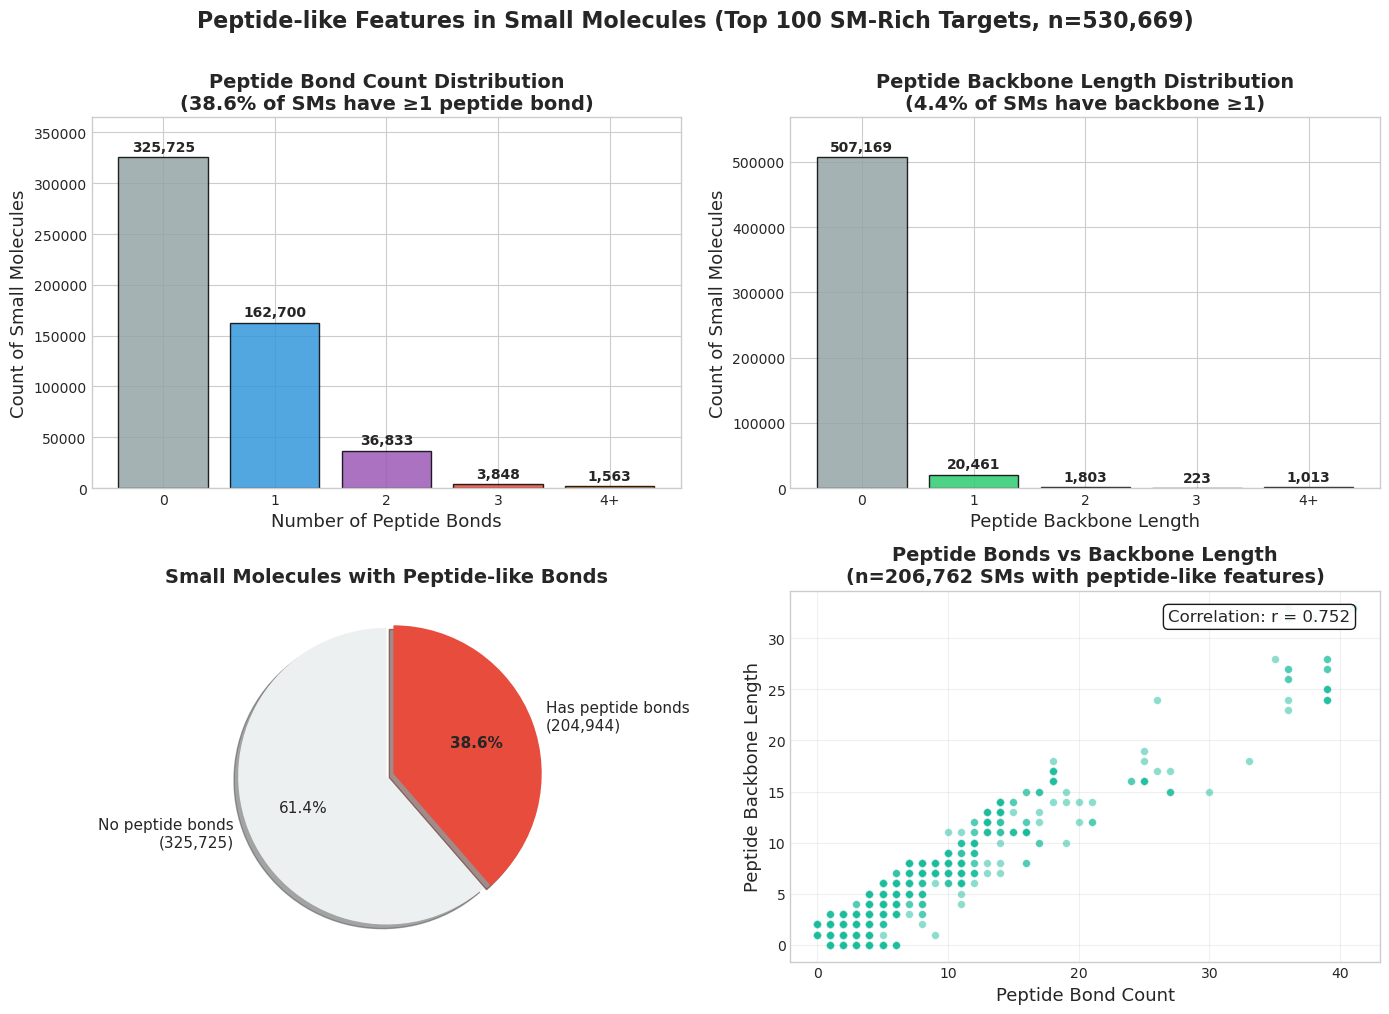


Saved plot to /fsx/amira/papyrus_50.5_results/classified_full_no_filter/peptide_features_in_sm.png


In [18]:
# =============================================================================
# STEP 4d (cont): Visualize Peptide Features Distribution in Small Molecules
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Get data
pbc = sm_features[pep_bond_col].fillna(0)
pbl = sm_features[pep_backbone_col].fillna(0)

# Calculate stats for annotations
n_total = len(pbc)
n_with_pep_bond = (pbc > 0).sum()
n_with_backbone = (pbl > 0).sum()
pct_with_pep_bond = n_with_pep_bond / n_total * 100
pct_with_backbone = n_with_backbone / n_total * 100

# ===================
# TOP LEFT: Peptide Bond Count - Category Bar Chart
# ===================
ax1 = axes[0, 0]
categories_pbc = pd.cut(pbc, bins=[-1, 0, 1, 2, 3, 100], labels=['0', '1', '2', '3', '4+'])
cat_counts_pbc = categories_pbc.value_counts().sort_index()
colors_pbc = ['#95a5a6', '#3498db', '#9b59b6', '#e74c3c', '#e67e22']
bars1 = ax1.bar(cat_counts_pbc.index, cat_counts_pbc.values, color=colors_pbc, alpha=0.85, edgecolor='black')
ax1.set_xlabel('Number of Peptide Bonds', fontsize=13)
ax1.set_ylabel('Count of Small Molecules', fontsize=13)
ax1.set_title(f'Peptide Bond Count Distribution\n({pct_with_pep_bond:.1f}% of SMs have ≥1 peptide bond)', 
              fontsize=14, fontweight='bold')
for bar, v in zip(bars1, cat_counts_pbc.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(cat_counts_pbc)*0.01, 
             f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_ylim(0, max(cat_counts_pbc) * 1.12)

# ===================
# TOP RIGHT: Peptide Backbone Length - Category Bar Chart
# ===================
ax2 = axes[0, 1]
categories_pbl = pd.cut(pbl, bins=[-1, 0, 1, 2, 3, 100], labels=['0', '1', '2', '3', '4+'])
cat_counts_pbl = categories_pbl.value_counts().sort_index()
colors_pbl = ['#95a5a6', '#2ecc71', '#27ae60', '#1abc9c', '#16a085']
bars2 = ax2.bar(cat_counts_pbl.index, cat_counts_pbl.values, color=colors_pbl, alpha=0.85, edgecolor='black')
ax2.set_xlabel('Peptide Backbone Length', fontsize=13)
ax2.set_ylabel('Count of Small Molecules', fontsize=13)
ax2.set_title(f'Peptide Backbone Length Distribution\n({pct_with_backbone:.1f}% of SMs have backbone ≥1)', 
              fontsize=14, fontweight='bold')
for bar, v in zip(bars2, cat_counts_pbl.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(cat_counts_pbl)*0.01, 
             f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylim(0, max(cat_counts_pbl) * 1.12)

# ===================
# BOTTOM LEFT: Pie Chart - With vs Without Peptide Bonds
# ===================
ax3 = axes[1, 0]
pie_data = [n_total - n_with_pep_bond, n_with_pep_bond]
pie_labels = [f'No peptide bonds\n({n_total - n_with_pep_bond:,})', 
              f'Has peptide bonds\n({n_with_pep_bond:,})']
pie_colors = ['#ecf0f1', '#e74c3c']
wedges, texts, autotexts = ax3.pie(pie_data, labels=pie_labels, colors=pie_colors, 
                                    autopct='%1.1f%%', startangle=90,
                                    explode=(0, 0.05), shadow=True,
                                    textprops={'fontsize': 11})
autotexts[1].set_fontweight('bold')
ax3.set_title('Small Molecules with Peptide-like Bonds', fontsize=14, fontweight='bold')

# ===================
# BOTTOM RIGHT: Scatter - Bond Count vs Backbone Length (non-zero only)
# ===================
ax4 = axes[1, 1]
mask_nonzero = (pbc > 0) | (pbl > 0)
if mask_nonzero.sum() > 0:
    ax4.scatter(pbc[mask_nonzero], pbl[mask_nonzero], 
                c='#1abc9c', alpha=0.5, s=30, edgecolors='white', linewidths=0.3)
    ax4.set_xlabel('Peptide Bond Count', fontsize=13)
    ax4.set_ylabel('Peptide Backbone Length', fontsize=13)
    ax4.set_title(f'Peptide Bonds vs Backbone Length\n(n={mask_nonzero.sum():,} SMs with peptide-like features)', 
                  fontsize=14, fontweight='bold')
    
    corr = np.corrcoef(pbc[mask_nonzero], pbl[mask_nonzero])[0,1]
    ax4.text(0.95, 0.95, f'Correlation: r = {corr:.3f}', transform=ax4.transAxes, fontsize=12, 
             ha='right', va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
    ax4.grid(True, alpha=0.3)

plt.suptitle(f'Peptide-like Features in Small Molecules (Top 100 SM-Rich Targets, n={n_total:,})', 
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/peptide_features_in_sm.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved plot to {OUTPUT_DIR}/peptide_features_in_sm.png")


In [19]:
# =============================================================================
# STEP 4e: Distribution of Peptide Features in ALL Small Molecules (Entire Dataset)
# =============================================================================

print("=" * 80)
print("STEP 4e: Peptide bond count & backbone length in ALL Small Molecules")
print("=" * 80)

# Get ALL unique SMILES classified as small molecules
all_sm_smiles = papyrus_df[papyrus_df['predicted_mol_class'] == 'sm']['SMILES'].unique()

print(f"\nTotal unique small molecule SMILES: {len(all_sm_smiles):,}")

# Get features for ALL small molecules
all_sm_features = features_df[features_df['SMILES'].isin(all_sm_smiles)].copy()

# Check column names
pep_bond_col_all = 'peptide_bond_count' if 'peptide_bond_count' in all_sm_features.columns else 'pattern_PEPTIDE_BOND'
pep_backbone_col_all = 'peptide_backbone_length' if 'peptide_backbone_length' in all_sm_features.columns else 'pattern_PEPTIDE_BACKBONE'

print(f"Using columns: {pep_bond_col_all}, {pep_backbone_col_all}")
print(f"\nSummary statistics for ALL small molecules:")

# Peptide bond count stats
if pep_bond_col_all in all_sm_features.columns:
    pbc_all = all_sm_features[pep_bond_col_all].fillna(0)
    print(f"\n  Peptide Bond Count:")
    print(f"    Mean: {pbc_all.mean():.3f}")
    print(f"    Median: {pbc_all.median():.3f}")
    print(f"    Max: {pbc_all.max():.0f}")
    print(f"    SMs with >=1 peptide bond: {(pbc_all >= 1).sum():,} ({(pbc_all >= 1).sum()/len(pbc_all)*100:.2f}%)")
    print(f"    SMs with >=2 peptide bonds: {(pbc_all >= 2).sum():,} ({(pbc_all >= 2).sum()/len(pbc_all)*100:.2f}%)")
    print(f"    SMs with >=3 peptide bonds: {(pbc_all >= 3).sum():,} ({(pbc_all >= 3).sum()/len(pbc_all)*100:.2f}%)")

# Peptide backbone length stats  
if pep_backbone_col_all in all_sm_features.columns:
    pbl_all = all_sm_features[pep_backbone_col_all].fillna(0)
    print(f"\n  Peptide Backbone Length:")
    print(f"    Mean: {pbl_all.mean():.3f}")
    print(f"    Median: {pbl_all.median():.3f}")
    print(f"    Max: {pbl_all.max():.0f}")
    print(f"    SMs with backbone >=1: {(pbl_all >= 1).sum():,} ({(pbl_all >= 1).sum()/len(pbl_all)*100:.2f}%)")
    print(f"    SMs with backbone >=2: {(pbl_all >= 2).sum():,} ({(pbl_all >= 2).sum()/len(pbl_all)*100:.2f}%)")


STEP 4e: Peptide bond count & backbone length in ALL Small Molecules


: 

In [ ]:
# =============================================================================
# STEP 4e (cont): Visualize Peptide Features in ALL Small Molecules
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

pbc_all = all_sm_features[pep_bond_col_all].fillna(0)
pbl_all = all_sm_features[pep_backbone_col_all].fillna(0)

n_total = len(pbc_all)
n_with_pep_bond = (pbc_all > 0).sum()
n_with_backbone = (pbl_all > 0).sum()
pct_with_pep_bond = n_with_pep_bond / n_total * 100
pct_with_backbone = n_with_backbone / n_total * 100

# TOP LEFT: Peptide Bond Count
ax1 = axes[0, 0]
categories_pbc = pd.cut(pbc_all, bins=[-1, 0, 1, 2, 3, 100], labels=['0', '1', '2', '3', '4+'])
cat_counts_pbc = categories_pbc.value_counts().sort_index()
colors_pbc = ['#95a5a6', '#3498db', '#9b59b6', '#e74c3c', '#e67e22']
bars1 = ax1.bar(cat_counts_pbc.index, cat_counts_pbc.values, color=colors_pbc, alpha=0.85, edgecolor='black')
ax1.set_xlabel('Number of Peptide Bonds', fontsize=13)
ax1.set_ylabel('Count of Small Molecules', fontsize=13)
ax1.set_title(f'Peptide Bond Count\n({pct_with_pep_bond:.1f}% have >= 1)', fontsize=14, fontweight='bold')
for bar, v in zip(bars1, cat_counts_pbc.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(cat_counts_pbc)*0.01, 
             f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_ylim(0, max(cat_counts_pbc) * 1.12)

# TOP RIGHT: Backbone Length
ax2 = axes[0, 1]
categories_pbl = pd.cut(pbl_all, bins=[-1, 0, 1, 2, 3, 100], labels=['0', '1', '2', '3', '4+'])
cat_counts_pbl = categories_pbl.value_counts().sort_index()
colors_pbl = ['#95a5a6', '#2ecc71', '#27ae60', '#1abc9c', '#16a085']
bars2 = ax2.bar(cat_counts_pbl.index, cat_counts_pbl.values, color=colors_pbl, alpha=0.85, edgecolor='black')
ax2.set_xlabel('Peptide Backbone Length', fontsize=13)
ax2.set_ylabel('Count of Small Molecules', fontsize=13)
ax2.set_title(f'Backbone Length\n({pct_with_backbone:.1f}% have >= 1)', fontsize=14, fontweight='bold')
for bar, v in zip(bars2, cat_counts_pbl.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(cat_counts_pbl)*0.01, 
             f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylim(0, max(cat_counts_pbl) * 1.12)

# BOTTOM LEFT: Pie Chart
ax3 = axes[1, 0]
pie_data = [n_total - n_with_pep_bond, n_with_pep_bond]
pie_labels = [f'No peptide bonds\n({n_total - n_with_pep_bond:,})', f'Has peptide bonds\n({n_with_pep_bond:,})']
wedges, texts, autotexts = ax3.pie(pie_data, labels=pie_labels, colors=['#ecf0f1', '#e74c3c'], 
                                    autopct='%1.1f%%', startangle=90, explode=(0, 0.05), shadow=True)
autotexts[1].set_fontweight('bold')
ax3.set_title('SMs with Peptide-like Bonds', fontsize=14, fontweight='bold')

# BOTTOM RIGHT: Scatter
ax4 = axes[1, 1]
mask_nonzero = (pbc_all > 0) | (pbl_all > 0)
if mask_nonzero.sum() > 0:
    ax4.scatter(pbc_all[mask_nonzero], pbl_all[mask_nonzero], c='#1abc9c', alpha=0.4, s=25, edgecolors='white')
    ax4.set_xlabel('Peptide Bond Count', fontsize=13)
    ax4.set_ylabel('Peptide Backbone Length', fontsize=13)
    ax4.set_title(f'Bond vs Backbone (n={mask_nonzero.sum():,})', fontsize=14, fontweight='bold')
    corr = np.corrcoef(pbc_all[mask_nonzero], pbl_all[mask_nonzero])[0,1]
    ax4.text(0.95, 0.95, f'r = {corr:.3f}', transform=ax4.transAxes, fontsize=12, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
    ax4.grid(True, alpha=0.3)

plt.suptitle(f'Peptide Features in ALL Small Molecules (n={n_total:,}) - Full Dataset', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/peptide_features_in_all_sm.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved to {OUTPUT_DIR}/peptide_features_in_all_sm.png")


STEP 5: Plotting pChEMBL distributions (records with activity only)

Records with activity values: 2,951,576
  Small molecules: 2,928,719
  Peptides: 15,707


/tmp/ipykernel_2365634/275150566.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='mol_class_label', y='pchembl_value_Mean',
/tmp/ipykernel_2365634/275150566.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='mol_class_label', y='pchembl_value_Mean',


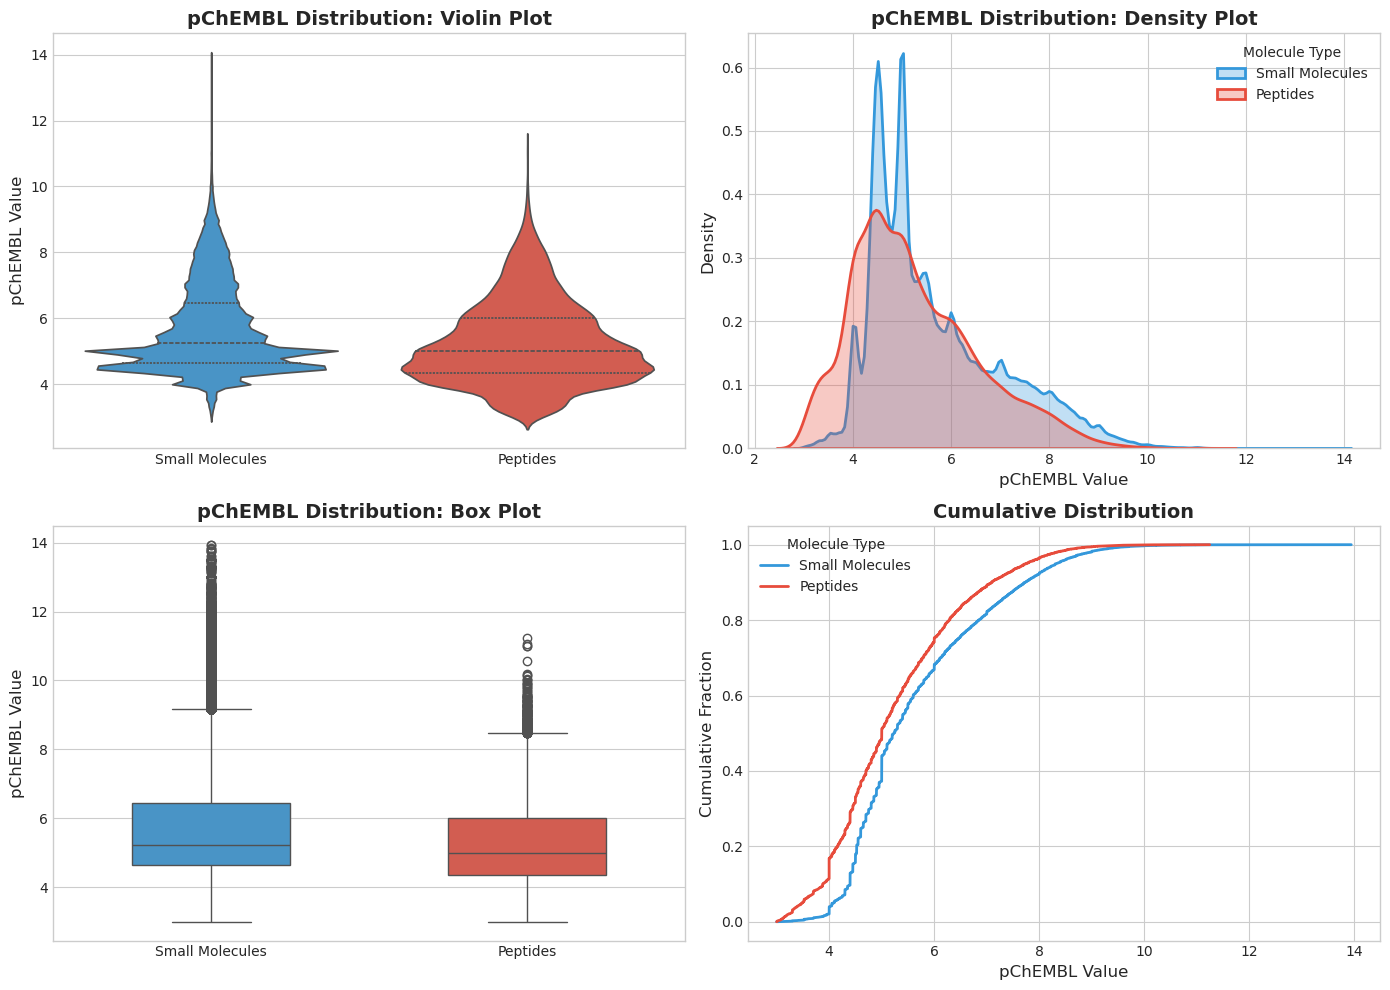


Saved plot to /fsx/amira/papyrus_50.5_results/classified_full_no_filter/pchembl_sm_vs_peptides.png


In [8]:
# =============================================================================
# STEP 5: Plot pChEMBL Distribution (for records WITH activity)
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 80)
print("STEP 5: Plotting pChEMBL distributions (records with activity only)")
print("=" * 80)

# Filter for records with activity
activity_df = papyrus_df[papyrus_df['pchembl_value_Mean'].notna()].copy()
plot_df = activity_df[activity_df['predicted_mol_class'].isin(['sm', 'can_peptide'])].copy()
plot_df['mol_class_label'] = plot_df['predicted_mol_class'].map({
    'sm': 'Small Molecules',
    'can_peptide': 'Peptides'
})

print(f"\nRecords with activity values: {len(activity_df):,}")
print(f"  Small molecules: {(plot_df['predicted_mol_class'] == 'sm').sum():,}")
print(f"  Peptides: {(plot_df['predicted_mol_class'] == 'can_peptide').sum():,}")

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Color palette
colors = {'Small Molecules': '#3498db', 'Peptides': '#e74c3c'}

# Plot 1: Violin plot
ax1 = axes[0, 0]
sns.violinplot(data=plot_df, x='mol_class_label', y='pchembl_value_Mean', 
               palette=colors, ax=ax1, inner='quartile')
ax1.set_xlabel('')
ax1.set_ylabel('pChEMBL Value', fontsize=12)
ax1.set_title('pChEMBL Distribution: Violin Plot', fontsize=14, fontweight='bold')

# Plot 2: KDE
ax2 = axes[0, 1]
for cls, color in colors.items():
    subset = plot_df[plot_df['mol_class_label'] == cls]['pchembl_value_Mean']
    sns.kdeplot(data=subset, ax=ax2, color=color, label=cls, fill=True, alpha=0.3, linewidth=2)
ax2.set_xlabel('pChEMBL Value', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('pChEMBL Distribution: Density Plot', fontsize=14, fontweight='bold')
ax2.legend(title='Molecule Type')

# Plot 3: Box plot
ax3 = axes[1, 0]
sns.boxplot(data=plot_df, x='mol_class_label', y='pchembl_value_Mean', 
            palette=colors, ax=ax3, width=0.5)
ax3.set_xlabel('')
ax3.set_ylabel('pChEMBL Value', fontsize=12)
ax3.set_title('pChEMBL Distribution: Box Plot', fontsize=14, fontweight='bold')

# Plot 4: Cumulative distribution
ax4 = axes[1, 1]
for cls, color in colors.items():
    subset = plot_df[plot_df['mol_class_label'] == cls]['pchembl_value_Mean'].sort_values()
    cumulative = np.arange(1, len(subset) + 1) / len(subset)
    ax4.plot(subset, cumulative, color=color, label=cls, linewidth=2)
ax4.set_xlabel('pChEMBL Value', fontsize=12)
ax4.set_ylabel('Cumulative Fraction', fontsize=12)
ax4.set_title('Cumulative Distribution', fontsize=14, fontweight='bold')
ax4.legend(title='Molecule Type')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/pchembl_sm_vs_peptides.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved plot to {OUTPUT_DIR}/pchembl_sm_vs_peptides.png")


STEP 6: MW vs pChEMBL scatter plot - Aggregated (Top 100 targets)

Data for top 100 targets (with activity):
  Small molecules: 223,863
  Peptides: 901


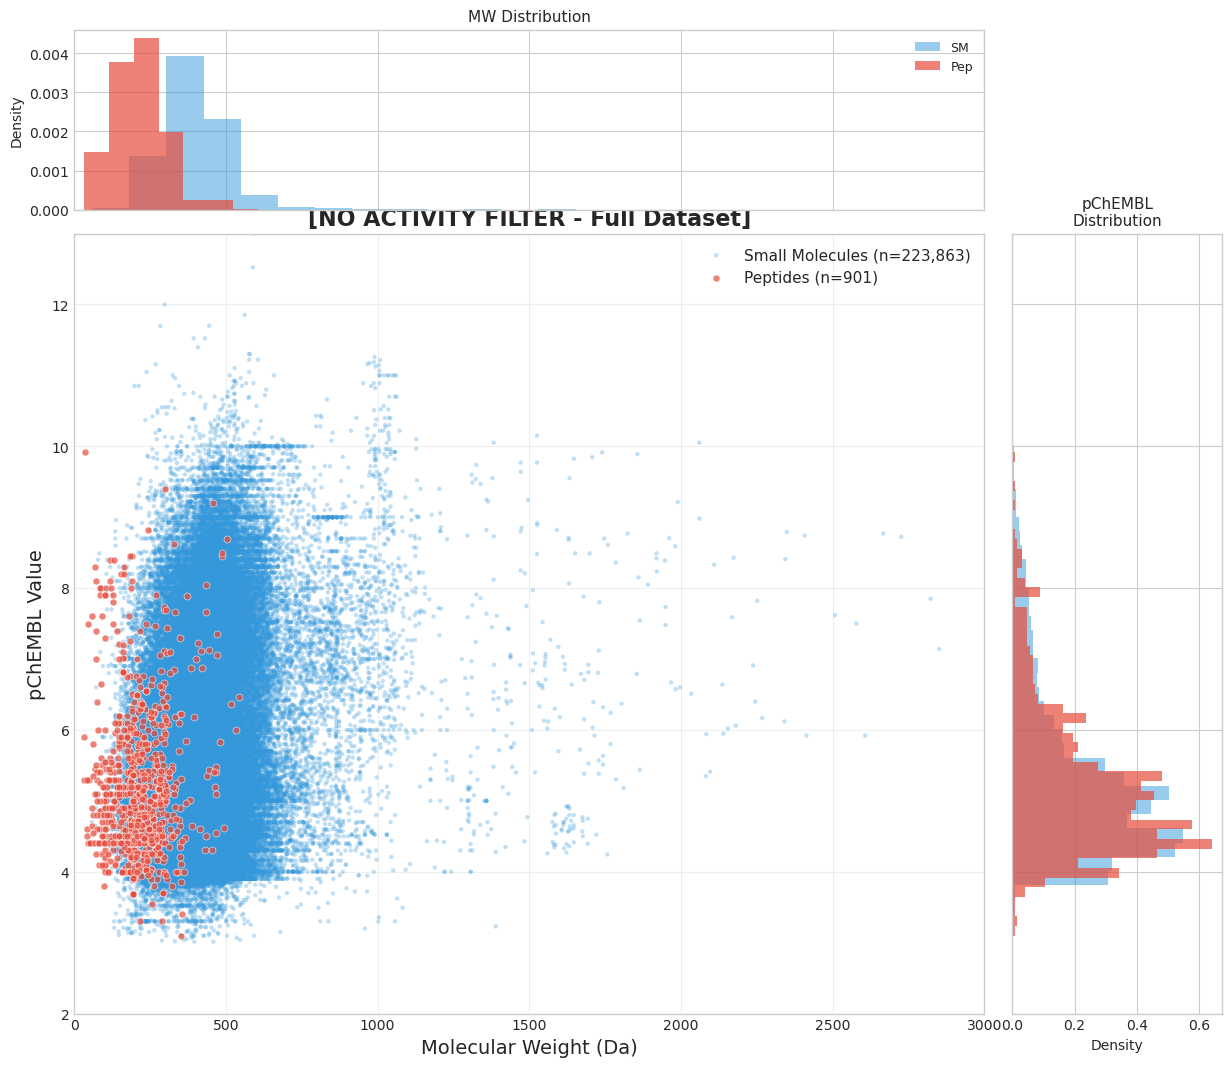


Saved aggregated plot to /fsx/amira/papyrus_50.5_results/classified_full_no_filter/mw_vs_pchembl_aggregated_top100.png

STATISTICS - Top 100 Targets (with activity)

Metric                         Small Molecules      Peptides            
----------------------------------------------------------------------
Count                          223,863            901
Mean MW                        399.7                225.5               
Median MW                      388.5                206.3               
Mean pChEMBL                   5.29                 5.22                
Median pChEMBL                 5.00                 5.00                


In [9]:
# =============================================================================
# STEP 6: MW vs pChEMBL - Aggregated (Top 100 targets with activity)
# =============================================================================

print("=" * 80)
print("STEP 6: MW vs pChEMBL scatter plot - Aggregated (Top 100 targets)")
print("=" * 80)

# Get top 100 targets by peptide count
top_100_targets = target_ranking.head(100)['accession'].tolist()

# Filter for top 100 targets with activity values
top100_data = papyrus_df[
    (papyrus_df['accession'].isin(top_100_targets)) & 
    (papyrus_df['pchembl_value_Mean'].notna())
].copy()
top100_data = top100_data[top100_data['predicted_mol_class'].isin(['sm', 'can_peptide'])]
top100_data = top100_data.dropna(subset=['molecular_weight', 'pchembl_value_Mean'])

sm_data = top100_data[top100_data['predicted_mol_class'] == 'sm']
pep_data = top100_data[top100_data['predicted_mol_class'] == 'can_peptide']

print(f"\nData for top 100 targets (with activity):")
print(f"  Small molecules: {len(sm_data):,}")
print(f"  Peptides: {len(pep_data):,}")

# Create figure with main scatter + marginal histograms
fig = plt.figure(figsize=(14, 12))

# Main scatter plot
ax_main = fig.add_axes([0.1, 0.1, 0.65, 0.65])

ax_main.scatter(sm_data['molecular_weight'], sm_data['pchembl_value_Mean'], 
               c='#3498db', alpha=0.3, s=10, label=f'Small Molecules (n={len(sm_data):,})', 
               edgecolors='none', rasterized=True)

ax_main.scatter(pep_data['molecular_weight'], pep_data['pchembl_value_Mean'], 
               c='#e74c3c', alpha=0.7, s=25, label=f'Peptides (n={len(pep_data):,})', 
               edgecolors='white', linewidths=0.5)

ax_main.set_xlabel('Molecular Weight (Da)', fontsize=14)
ax_main.set_ylabel('pChEMBL Value', fontsize=14)
ax_main.set_title('Molecular Weight vs Activity (Top 100 Peptide-Rich Targets)\n[NO ACTIVITY FILTER - Full Dataset]', 
                  fontsize=16, fontweight='bold')
ax_main.legend(loc='upper right', fontsize=11)
ax_main.set_xlim(0, 3000)
ax_main.set_ylim(2, 13)
ax_main.grid(True, alpha=0.3)

# Top histogram (MW distribution)
ax_top = fig.add_axes([0.1, 0.77, 0.65, 0.15], sharex=ax_main)
ax_top.hist(sm_data['molecular_weight'], bins=50, color='#3498db', alpha=0.5, label='SM', density=True)
ax_top.hist(pep_data['molecular_weight'], bins=50, color='#e74c3c', alpha=0.7, label='Pep', density=True)
ax_top.set_ylabel('Density', fontsize=10)
ax_top.set_title('MW Distribution', fontsize=11)
ax_top.tick_params(labelbottom=False)
ax_top.legend(fontsize=9)

# Right histogram (pChEMBL distribution)
ax_right = fig.add_axes([0.77, 0.1, 0.15, 0.65], sharey=ax_main)
ax_right.hist(sm_data['pchembl_value_Mean'], bins=50, color='#3498db', alpha=0.5, 
              orientation='horizontal', density=True)
ax_right.hist(pep_data['pchembl_value_Mean'], bins=50, color='#e74c3c', alpha=0.7, 
              orientation='horizontal', density=True)
ax_right.set_xlabel('Density', fontsize=10)
ax_right.set_title('pChEMBL\nDistribution', fontsize=11)
ax_right.tick_params(labelleft=False)

plt.savefig(f"{OUTPUT_DIR}/mw_vs_pchembl_aggregated_top100.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved aggregated plot to {OUTPUT_DIR}/mw_vs_pchembl_aggregated_top100.png")

# Print statistics
print(f"\n{'='*70}")
print("STATISTICS - Top 100 Targets (with activity)")
print(f"{'='*70}")
print(f"\n{'Metric':<30} {'Small Molecules':<20} {'Peptides':<20}")
print("-" * 70)
print(f"{'Count':<30} {len(sm_data):,}{'':<11} {len(pep_data):,}")
print(f"{'Mean MW':<30} {sm_data['molecular_weight'].mean():<20.1f} {pep_data['molecular_weight'].mean():<20.1f}")
print(f"{'Median MW':<30} {sm_data['molecular_weight'].median():<20.1f} {pep_data['molecular_weight'].median():<20.1f}")
print(f"{'Mean pChEMBL':<30} {sm_data['pchembl_value_Mean'].mean():<20.2f} {pep_data['pchembl_value_Mean'].mean():<20.2f}")
print(f"{'Median pChEMBL':<30} {sm_data['pchembl_value_Mean'].median():<20.2f} {pep_data['pchembl_value_Mean'].median():<20.2f}")


STEP 7: MW vs pChEMBL scatter plots per target (Top 100)

Creating scatter plots for 100 targets...


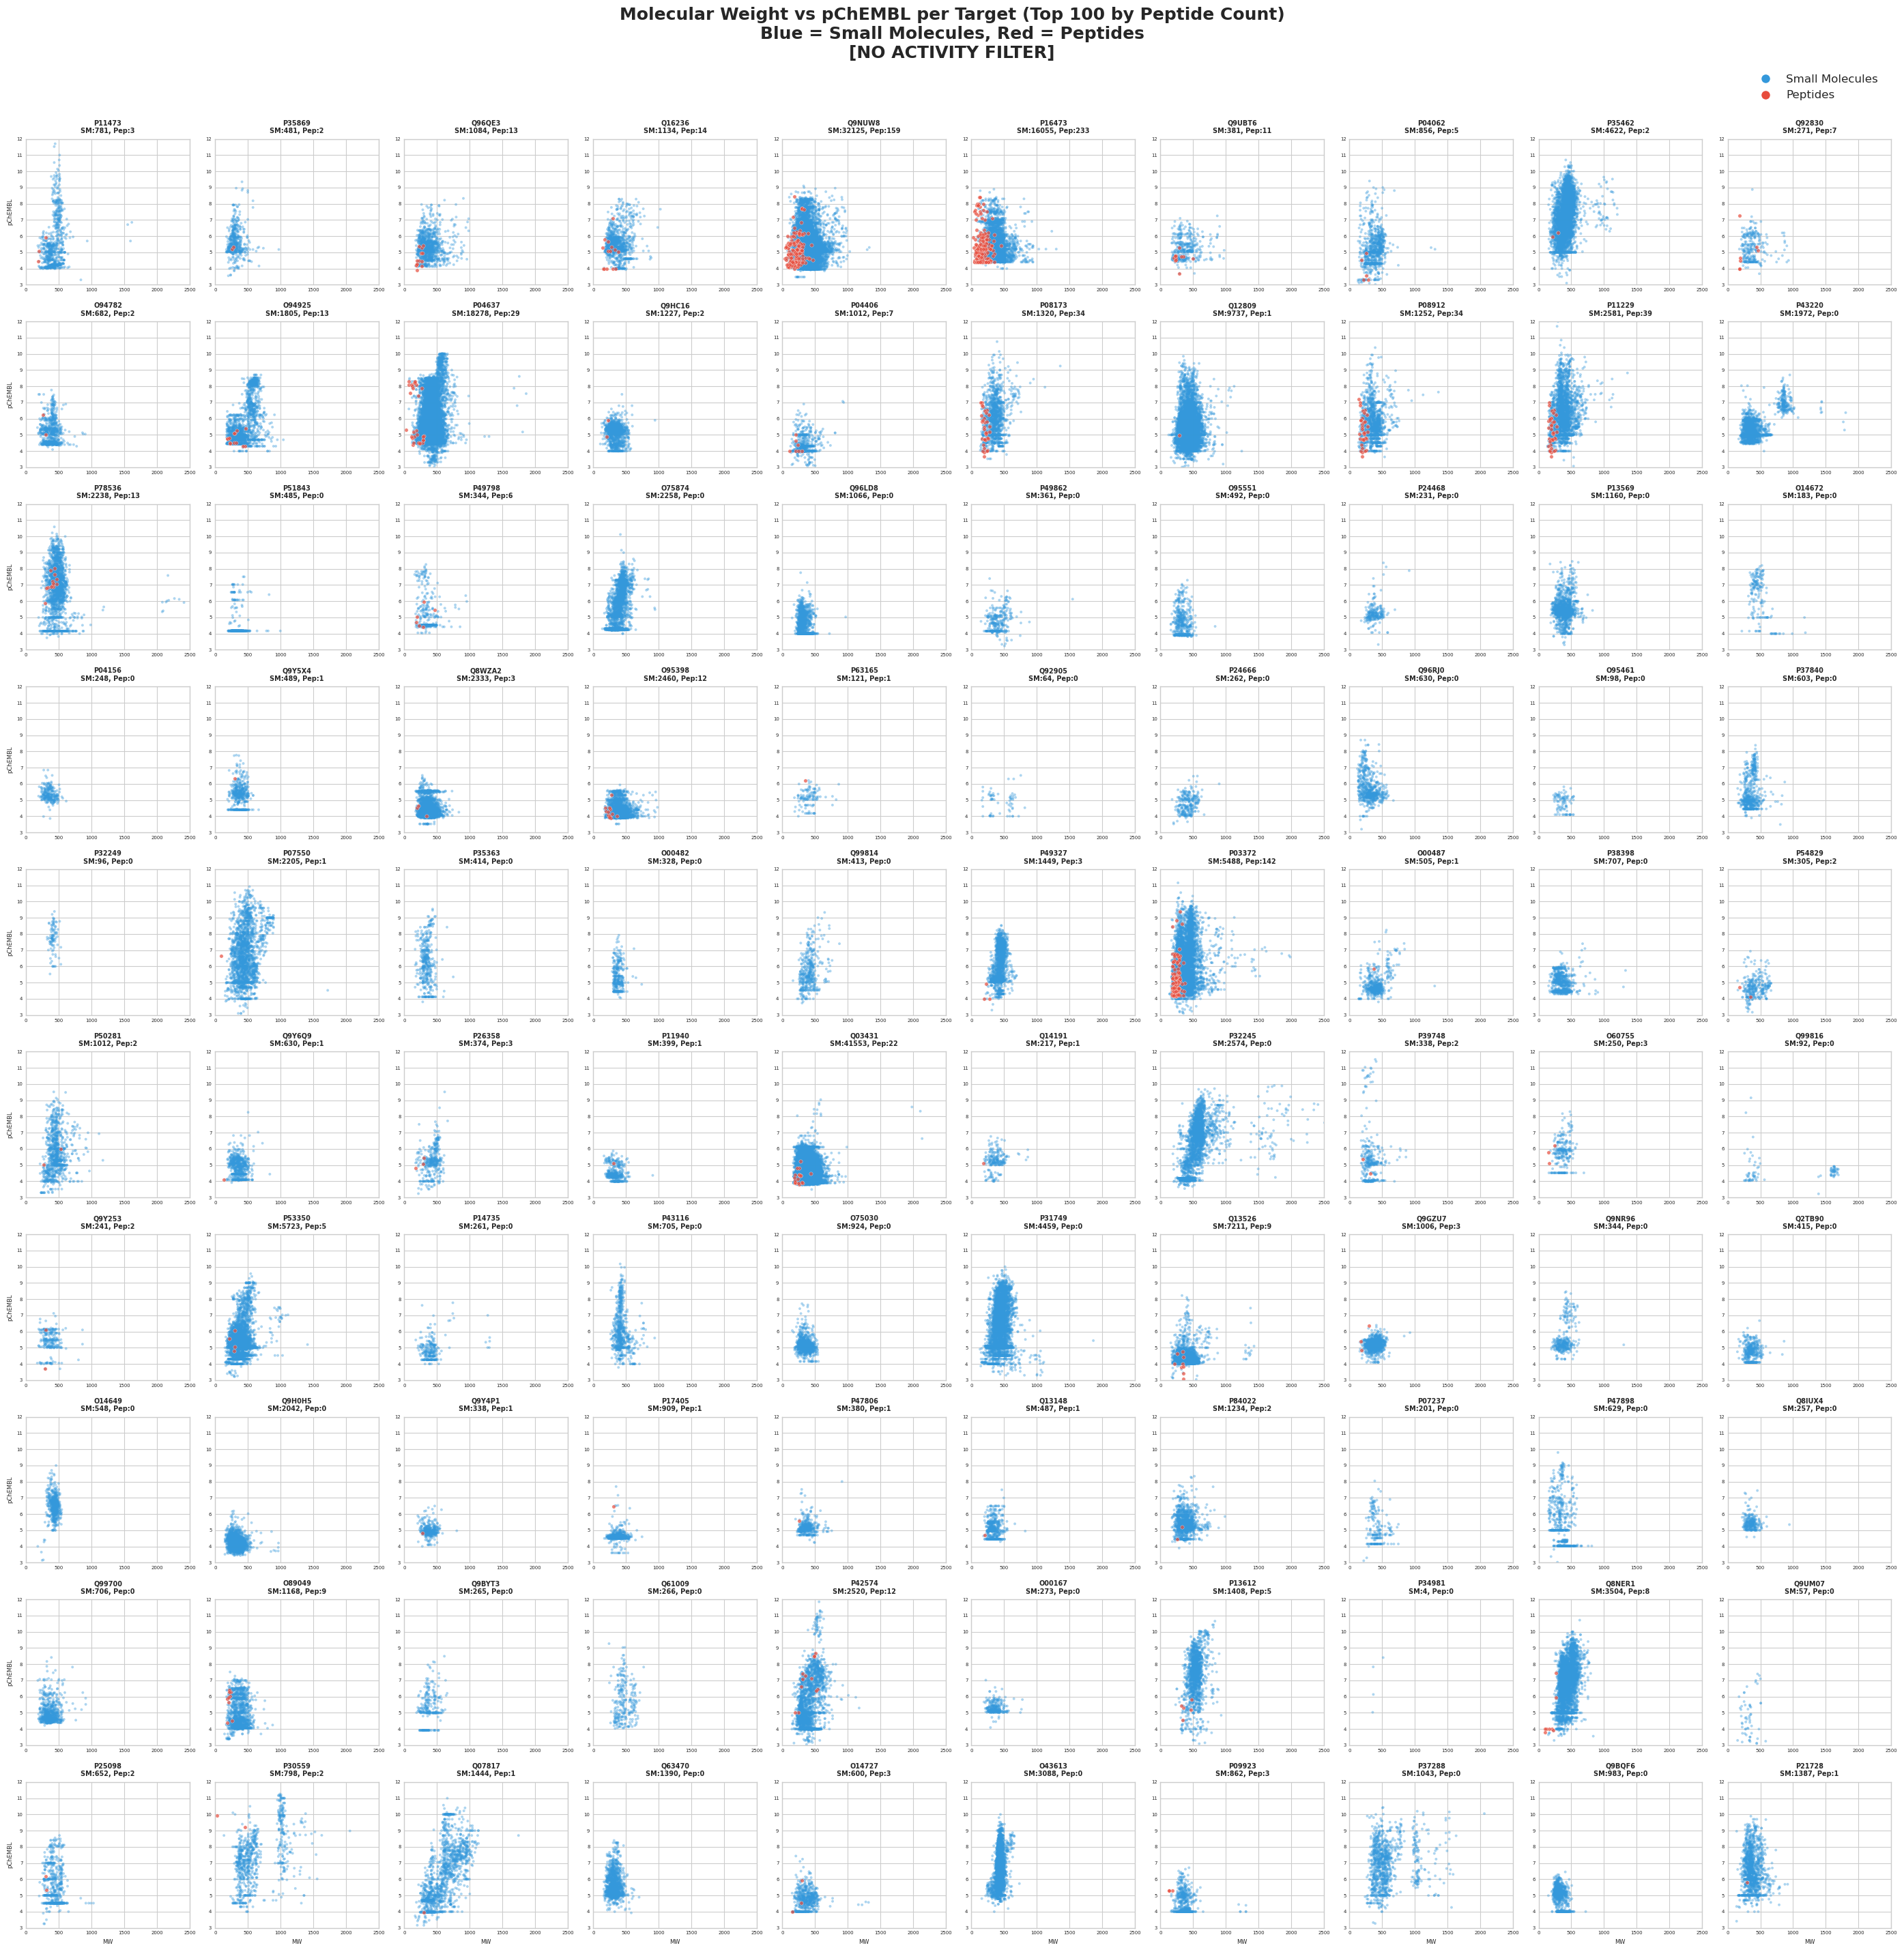


Saved scatter plot grid to /fsx/amira/papyrus_50.5_results/classified_full_no_filter/mw_vs_pchembl_per_target_top100.png


In [12]:
# =============================================================================
# STEP 7: MW vs pChEMBL per Target Grid (Top 100)
# =============================================================================

print("=" * 80)
print("STEP 7: MW vs pChEMBL scatter plots per target (Top 100)")
print("=" * 80)

# Create 10x10 grid of scatter plots
n_cols = 10
n_rows = 10
fig, axes = plt.subplots(n_rows, n_cols, figsize=(28, 28))
axes = axes.flatten()

print(f"\nCreating scatter plots for {len(top_100_targets)} targets...")

for idx, acc in enumerate(top_100_targets):
    ax = axes[idx]
    
    target_data = papyrus_df[
        (papyrus_df['accession'] == acc) & 
        (papyrus_df['pchembl_value_Mean'].notna())
    ].copy()
    target_data = target_data[target_data['predicted_mol_class'].isin(['sm', 'can_peptide'])]
    target_data = target_data.dropna(subset=['molecular_weight', 'pchembl_value_Mean'])
    
    if len(target_data) > 0:
        sm_vals = target_data[target_data['predicted_mol_class'] == 'sm']
        pep_vals = target_data[target_data['predicted_mol_class'] == 'can_peptide']
        
        if len(sm_vals) > 0:
            ax.scatter(sm_vals['molecular_weight'], sm_vals['pchembl_value_Mean'], 
                      c='#3498db', alpha=0.4, s=8, edgecolors='none')
        
        if len(pep_vals) > 0:
            ax.scatter(pep_vals['molecular_weight'], pep_vals['pchembl_value_Mean'], 
                      c='#e74c3c', alpha=0.7, s=15, edgecolors='white', linewidths=0.3)
        
        ax.set_xlim(0, 2500)
        ax.set_ylim(3, 12)
        
        n_sm = len(sm_vals)
        n_pep = len(pep_vals)
        ax.set_title(f'{acc}\nSM:{n_sm}, Pep:{n_pep}', fontsize=7, fontweight='bold')
        
        ax.tick_params(axis='both', labelsize=5)
        
        if idx % n_cols == 0:
            ax.set_ylabel('pChEMBL', fontsize=6)
        if idx >= (n_rows - 1) * n_cols:
            ax.set_xlabel('MW', fontsize=6)
    else:
        ax.set_visible(False)

fig.suptitle('Molecular Weight vs pChEMBL per Target (Top 100 by Peptide Count)\nBlue = Small Molecules, Red = Peptides\n[NO ACTIVITY FILTER]', 
             fontsize=18, fontweight='bold', y=1.02)

handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=10, label='Small Molecules'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='Peptides')
]
fig.legend(handles=handles, loc='upper right', fontsize=12, bbox_to_anchor=(0.99, 0.99))

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/mw_vs_pchembl_per_target_top100.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved scatter plot grid to {OUTPUT_DIR}/mw_vs_pchembl_per_target_top100.png")


In [13]:
# =============================================================================
# STEP 8: Overlap with Target Prioritization List
# =============================================================================

print("=" * 80)
print("STEP 8: Checking overlap with Target Prioritization List")
print("=" * 80)

# Load target prioritization file
prioritization_file = "/fsx/amira/papyrus_target_prioritization/TargetPrioritization_PBS_IDs_Nov2025.csv"

try:
    priority_df = pd.read_csv(prioritization_file)
    print(f"\nLoaded prioritization file: {prioritization_file}")
    print(f"Number of priority targets: {len(priority_df)}")
    print(f"Columns: {priority_df.columns.tolist()}")
    
    # Get UniProt IDs from prioritization file
    uniprot_col = None
    for col in ['UniProt_ID', 'UniProtID', 'uniprot_id', 'accession', 'Accession', 'UniProt', 'ID']:
        if col in priority_df.columns:
            uniprot_col = col
            break
    
    if uniprot_col is None:
        print("\nAvailable columns:")
        print(priority_df.head())
    else:
        priority_targets = set(priority_df[uniprot_col].dropna().unique())
        print(f"\nUsing column '{uniprot_col}' for UniProt IDs")
        print(f"Unique priority targets: {len(priority_targets)}")
        
        # Get top 100 targets from our ranking
        top_100_set = set(target_ranking.head(100)['accession'].tolist())
        
        # Find overlaps
        overlap = top_100_set.intersection(priority_targets)
        
        print(f"\n{'='*60}")
        print("OVERLAP ANALYSIS")
        print(f"{'='*60}")
        print(f"\nTop 100 peptide-rich targets: {len(top_100_set)}")
        print(f"Priority targets: {len(priority_targets)}")
        print(f"OVERLAP: {len(overlap)} targets ({len(overlap)/len(top_100_set)*100:.1f}% of top 100)")
        
        if len(overlap) > 0:
            print(f"\n{'='*60}")
            print("OVERLAPPING TARGETS")
            print(f"{'='*60}")
            
            overlap_details = target_ranking[target_ranking['accession'].isin(overlap)].copy()
            overlap_details = overlap_details.sort_values('rank')
            
            print(f"\n{'Rank':<6} {'Target':<15} {'Peptides':<12} {'SMs':<12} {'%Peptide':<10}")
            print("-" * 60)
            for _, row in overlap_details.iterrows():
                print(f"{row['rank']:<6} {row['accession']:<15} {row['can_peptide']:<12} {row['sm']:<12} {row['peptide_percent']:.1f}%")
            
            overlap_output = f"{OUTPUT_DIR}/overlap_priority_top100_peptide.tsv"
            overlap_details.to_csv(overlap_output, sep='\t', index=False)
            print(f"\nSaved overlap details to {overlap_output}")
            
except FileNotFoundError:
    print(f"\nPrioritization file not found: {prioritization_file}")
    print("Skipping overlap analysis.")


STEP 8: Checking overlap with Target Prioritization List

Loaded prioritization file: /fsx/amira/papyrus_target_prioritization/TargetPrioritization_PBS_IDs_Nov2025.csv
Number of priority targets: 56
Columns: ['Gene name', 'Protein name', 'Cortellis', 'ChEMBL', 'Uniprot ID', 'Protein sequence', 'PDB apo', 'PDB holo + peptide', 'PDB holo + SM']

Available columns:
         Gene name                                       Protein name  \
0            GLP1R                   glucagon like peptide 1 receptor   
1             GCGR                                  glucagon receptor   
2             GIPR            gastric inhibitory polypeptide receptor   
3  Amylin receptor  calcitonin receptor + RAMP complex (AMY receptor)   
4            GLP2R                   glucagon like peptide 2 receptor   

  Cortellis ChEMBL      Uniprot ID  \
0         +      +          P43220   
1         +      +          P47871   
2         +      +          P48546   
3         +    NaN  P30988 + RAMPs   
4     

In [14]:
# =============================================================================
# STEP 9: Save Results
# =============================================================================

print("=" * 80)
print("STEP 9: Saving results")
print("=" * 80)

# 1. Save unique SMILES with features and predictions
features_df['predicted_mol_class'] = features_df['SMILES'].map(smiles_to_pred)
output_features = f"{OUTPUT_DIR}/papyrus_unique_smiles_features.tsv.xz"
features_df.to_csv(output_features, sep='\t', index=False, compression='xz')
print(f"\n  Saved {len(features_df):,} unique SMILES with features to {output_features}")

# 2. Save class pivot table
pivot = papyrus_df.groupby(['accession', 'predicted_mol_class'])['SMILES'].nunique().unstack(fill_value=0)
output_pivot = f"{OUTPUT_DIR}/papyrus_target_class_pivot.tsv"
pivot.to_csv(output_pivot, sep='\t')
print(f"  Saved pivot table to {output_pivot}")

# 3. Save peptides only (unique SMILES)
peptide_smiles = features_df[features_df['predicted_mol_class'] == 'can_peptide']
if len(peptide_smiles) > 0:
    output_pep = f"{OUTPUT_DIR}/papyrus_peptide_smiles.tsv.xz"
    peptide_smiles.to_csv(output_pep, sep='\t', index=False, compression='xz')
    print(f"  Saved {len(peptide_smiles):,} unique peptide SMILES to {output_pep}")

print(f"\n" + "=" * 80)
print("PIPELINE COMPLETE")
print("=" * 80)


STEP 9: Saving results

  Saved 1,424,987 unique SMILES with features to /fsx/amira/papyrus_50.5_results/classified_full_no_filter/papyrus_unique_smiles_features.tsv.xz
  Saved pivot table to /fsx/amira/papyrus_50.5_results/classified_full_no_filter/papyrus_target_class_pivot.tsv
  Saved 6,683 unique peptide SMILES to /fsx/amira/papyrus_50.5_results/classified_full_no_filter/papyrus_peptide_smiles.tsv.xz

PIPELINE COMPLETE


In [ ]:
# =============================================================================
# Summary Statistics
# =============================================================================

print("\n" + "=" * 80)
print("FINAL SUMMARY")
print("=" * 80)

print(f"\nDataset Statistics:")
print(f"  Total records: {len(papyrus_df):,}")
print(f"  Unique SMILES: {papyrus_df['SMILES'].nunique():,}")
print(f"  Unique targets: {papyrus_df['accession'].nunique():,}")
print(f"  Records with activity: {papyrus_df['pchembl_value_Mean'].notna().sum():,}")
print(f"  Records without activity: {papyrus_df['pchembl_value_Mean'].isna().sum():,}")

print(f"\nClassification Results (unique SMILES):")
for cls in ['sm', 'can_peptide', 'unwanted']:
    count = (features_df['predicted_mol_class'] == cls).sum()
    pct = count / len(features_df) * 100
    print(f"  {cls}: {count:,} ({pct:.2f}%)")

print(f"\nOutput Files:")
print(f"  {OUTPUT_DIR}/")
for f in sorted(os.listdir(OUTPUT_DIR)):
    fpath = f"{OUTPUT_DIR}/{f}"
    size_mb = os.path.getsize(fpath) / (1024*1024)
    print(f"    - {f} ({size_mb:.1f} MB)")
